# Predict House Price with Linear Regression

## Objective

Based on the past data on house sales and other information about the sample sales, build up a linear regression model to predict the house price of :
- Area: 6500$ft^2$,
- Bedrooms: 4,
- Bathrooms: 2,
- Stories: 2,
- Mainroad: No,
- Guestroom: No,
- Basement: Yes,
- Hot water heating: Yes,
- Air conditioning: No,
- Parking spot: 2,
- Preferred area: Yes
- Furnishing status: Semi-furnishing


## Basic Info

The dataset `house_price.csv` records the closed price of over 500 houses, and other information of the house.

Meaning of the columns in `house_price.csv`:
- price: Selling price of the house
- area: House area, in $ft^2$
- bedrooms: Number of bedrooms
- bathrooms: Number of bathrooms
- stories: Number of floors
- mainroad: If the house is next to mainroad
   - yes  
   - no	  
- guestroom: If the house has guestroom
   - yes  
   - no	 
- basement: If the house has a basement
   - yes  
   - no	  
- hotwaterheating: If the house has hot water heating
   - yes  
   - no	  
- airconditioning: If the house has air conditioning
   - yes  
   - no	  
- parking: Parking capacity, in number of cars
- prefarea: If the house is in the preferred area of the city
   - yes  
   - no	  
- furnishingstatus: Furnishing status
   - furnished      
   - semi-furnished	 
   - unfurnished     

### Read the Data

Import the packages needed.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

A new DataFrame `original_house_price` is established as the name of 'house_price.csv'.

In [2]:
original_house_price = pd.read_csv('house_price.csv')
original_house_price.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Evaluate and Clean

In this part, the data will be evaluated and cleaned in several dimensions:
- Structure (Tidiness)
- Content (Clean)

A new DataFrame `cleaned_house_price` will be developed as a copy of `original_house_price`. The following evaluating and cleaning processes will be done on `cleaned_house_price`.

In [3]:
cleaned_house_price = original_house_price.copy()
cleaned_house_price.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#### Extent of Tidiness

In [4]:
cleaned_house_price.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


From the top 10 lines of the dataset, it is tidy enough. No action needed.

#### Extent of Clean

Scan the dataset via `info`.

In [5]:
cleaned_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


From the result, we can get:
- There are 545 observations in total
- `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`, and `furnishingstatus` are categorical data. We will change their datatype to `category`.

In [6]:
cleaned_house_price['mainroad'] = cleaned_house_price['mainroad'].astype('category')
cleaned_house_price['guestroom'] = cleaned_house_price['guestroom'].astype('category')
cleaned_house_price['basement'] = cleaned_house_price['basement'].astype('category')
cleaned_house_price['hotwaterheating'] = cleaned_house_price['hotwaterheating'].astype('category')
cleaned_house_price['airconditioning'] = cleaned_house_price['airconditioning'].astype('category')
cleaned_house_price['prefarea'] = cleaned_house_price['prefarea'].astype('category')
cleaned_house_price['furnishingstatus'] = cleaned_house_price['furnishingstatus'].astype('category')

In [7]:
cleaned_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 30.3 KB


##### Missing Value

According to the result from `info`, there is no missing value.

##### Duplicate Value

According to the meaning of each column, it is allowed to have duplicate values/variables.

##### Inconsistant Values

Inconsistant values possibly occur in every categorical data columns. We need to check if more than one value means the same.

In [8]:
cleaned_house_price['mainroad'].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [9]:
cleaned_house_price['guestroom'].value_counts()

guestroom
no     448
yes     97
Name: count, dtype: int64

In [10]:
cleaned_house_price['basement'].value_counts()

basement
no     354
yes    191
Name: count, dtype: int64

In [11]:
cleaned_house_price['hotwaterheating'].value_counts()

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

In [12]:
cleaned_house_price['airconditioning'].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

In [13]:
cleaned_house_price['prefarea'].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

In [14]:
cleaned_house_price['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

No inconsistant values detected.

##### Invalid and Wrong Value

In [15]:
cleaned_house_price.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


No invalid and wrong data detected.

### Explore the Data

Before the actual analysis starts, some data exploration with the graphs are helpful.

In [17]:
sns.set_palette('pastel')

#### Distribution of House Price

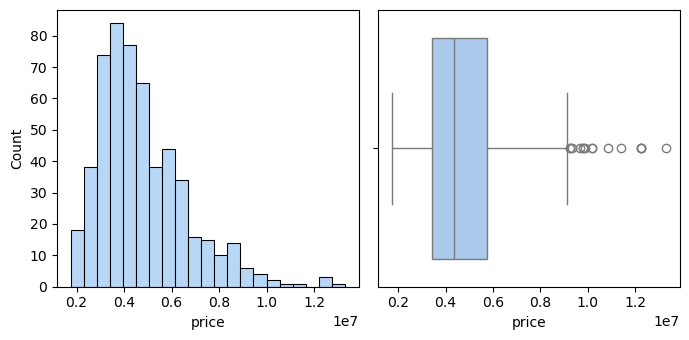

In [23]:
plt.rcParams["figure.figsize"] = [7.00, 3.50]
plt.rcParams["figure.autolayout"] = True
figure, axes = plt.subplots(1, 2)

sns.histplot(cleaned_house_price, x = 'price', ax = axes[0])
sns.boxplot(cleaned_house_price, x = 'price', ax = axes[1])
plt.show()

As shown on the plots above, the distribution of house price is right-skewed. Most of the price is 3500000 to 6000000 currency units.

#### Distribution of Area

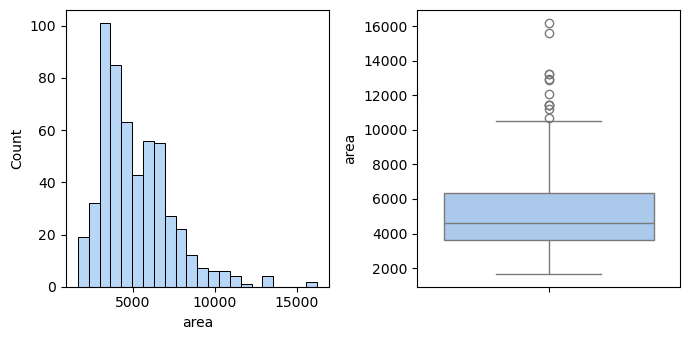

In [24]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='area', ax=axes[0])
sns.boxplot(cleaned_house_price, y='area', ax=axes[1])
plt.show()

Similar to the house price, the distributino of house area is right-skewed too.

#### The Relation bewteen Price and Area

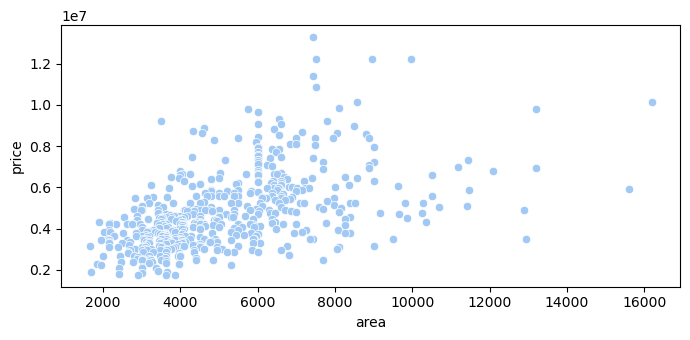

In [26]:
sns.scatterplot(cleaned_house_price, x = 'area', y = 'price')
plt.show()

From the plot above, we can see a moderate positive relation, but further interpretation is needed.

#### Number of Bedrooms and Price

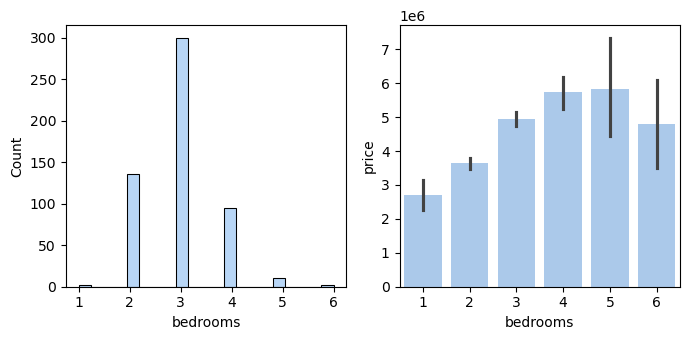

In [28]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='bedrooms', ax=axes[0])
sns.barplot(cleaned_house_price, x='bedrooms', y='price', ax=axes[1])
plt.show()

As shown on the graphs above, we can see:
- Most of the samples have 3 bedrooms.
- When the unit has less than 5 bedrooms, the price goes up as the bedroom number increase.
  

#### Number of Bathrooms and Price

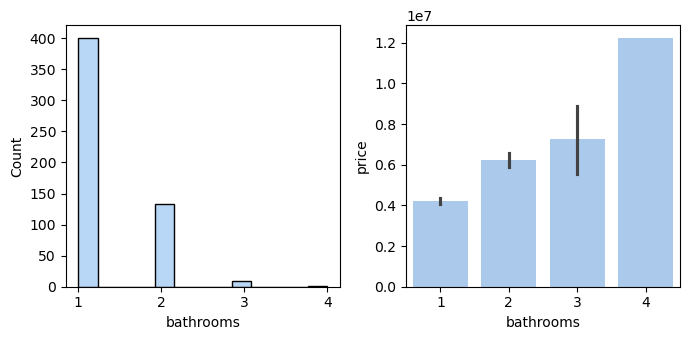

In [29]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='bathrooms', ax=axes[0])
sns.barplot(cleaned_house_price, x='bathrooms', y='price', ax=axes[1])
plt.show()

From the graph above, we can see:
- Most samples have 1 bathroom.
- As the number of bathrooms goes up, the house price increases.

#### Number of Floors and Price

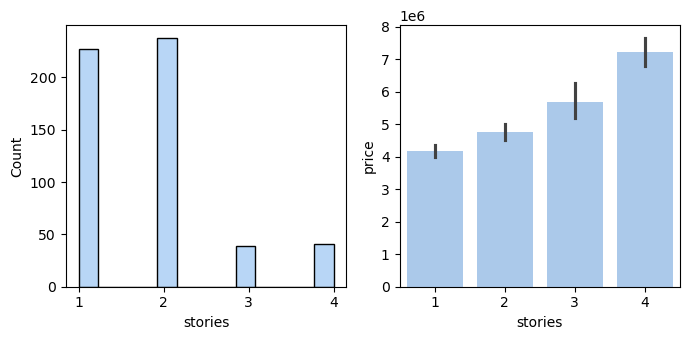

In [30]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='stories', ax=axes[0])
sns.barplot(cleaned_house_price, x='stories', y='price', ax=axes[1])
plt.show()

From the plots above, we can see:
- Most samples have 1 and 2 floors.
- As the number of floors goes up, the price increases.

#### Parking Capacity and Price

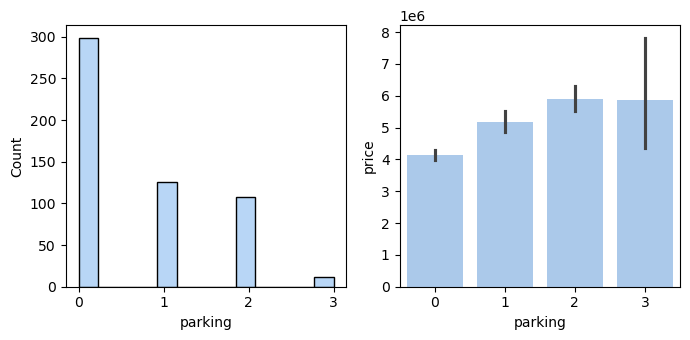

In [31]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='parking', ax=axes[0])
sns.barplot(cleaned_house_price, x='parking', y='price', ax=axes[1])
plt.show()

From the plots above, we can see:
- Most samples have 0-2 parking spaces.
- When there is less than 3 parking spaces, price goes up as the parking spaces increases.

#### Mainroad or not and Price

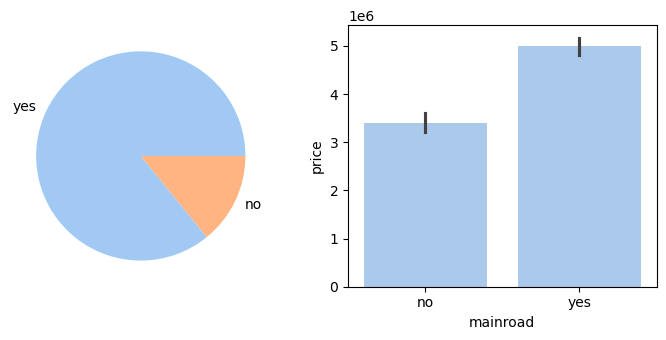

In [37]:
figure, axes = plt.subplots(1, 2)
mainroad_count = cleaned_house_price['mainroad'].value_counts()
mainroad_label = mainroad_count.index
axes[0].pie(mainroad_count, labels = mainroad_label)
sns.barplot(cleaned_house_price, x = 'mainroad', y = 'price', ax = axes[1])
plt.show()

From the graphs above, we can see:
- Most of the samples are located near the mainroad.
- The ones close to mainroad have higher price.

#### Guestroom or not and Price

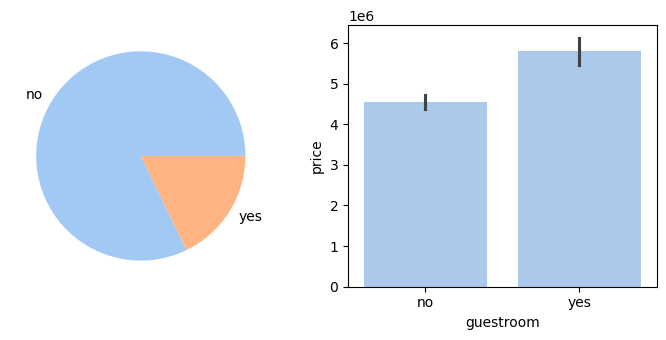

In [38]:
figure, axes = plt.subplots(1, 2)
guestroom_count = cleaned_house_price['guestroom'].value_counts()
guestroom_label = guestroom_count.index
axes[0].pie(guestroom_count, labels=guestroom_label)
sns.barplot(cleaned_house_price, x='guestroom', y='price', ax=axes[1])
plt.show()

From the graph above, we can see that:
- Most of the samples do not have a guestroom.
- The ones with guestroom are priced higher.

#### Basement or not and Price

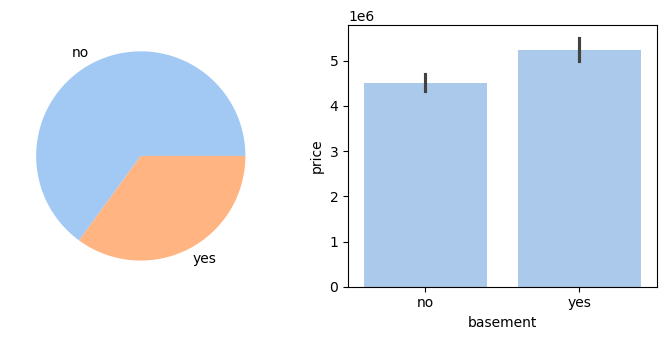

In [39]:
figure, axes = plt.subplots(1, 2)
basement_count = cleaned_house_price['basement'].value_counts()
basement_label = basement_count.index
axes[0].pie(basement_count, labels=basement_label)
sns.barplot(cleaned_house_price, x='basement', y='price', ax=axes[1])
plt.show()

From the graphs above, we can see that:
- Most samples do not have basement.
- The ones with a basement are priced higher.

#### Hot Water Heating and Price

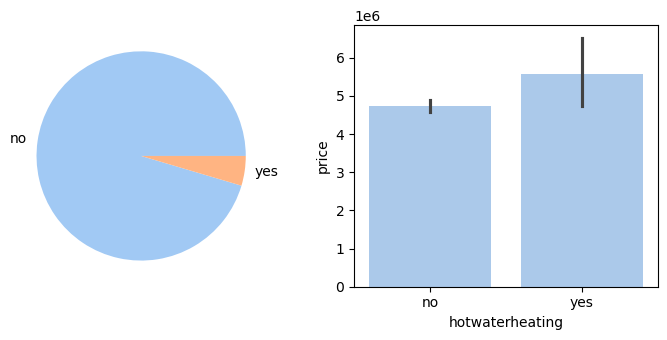

In [40]:
figure, axes = plt.subplots(1, 2)
hotwaterheating_count = cleaned_house_price['hotwaterheating'].value_counts()
hotwaterheating_label = hotwaterheating_count.index
axes[0].pie(hotwaterheating_count, labels=hotwaterheating_label)
sns.barplot(cleaned_house_price, x='hotwaterheating', y='price', ax=axes[1])
plt.show()

#### Air Conditioning and Price

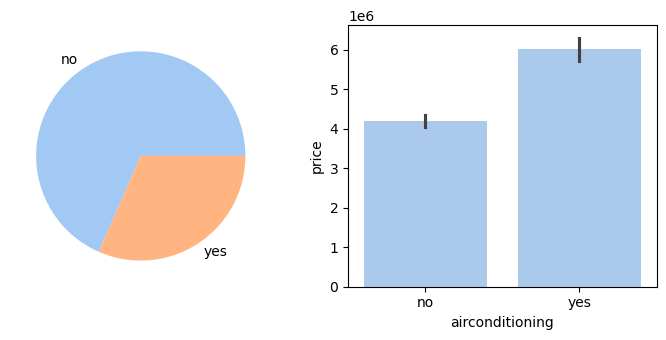

In [41]:
figure, axes = plt.subplots(1, 2)
airconditioning_count = cleaned_house_price['airconditioning'].value_counts()
airconditioning_label = airconditioning_count.index
axes[0].pie(airconditioning_count, labels=airconditioning_label)
sns.barplot(cleaned_house_price, x='airconditioning', y='price', ax=axes[1])
plt.show()

From the graphs above, we can see that:
- Most of the samples do not have air conditioning.
- The ones with air conditionding are priced higher.

#### Preferred Area and Price

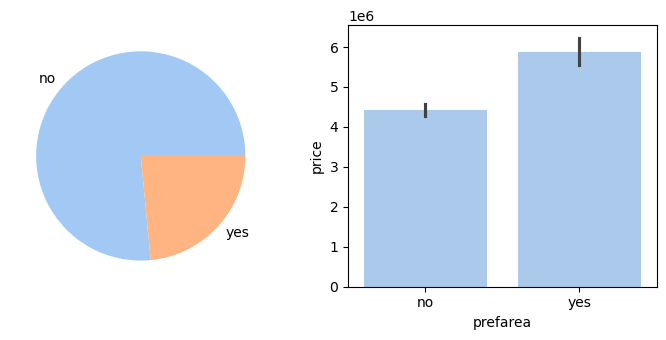

In [42]:
figure, axes = plt.subplots(1, 2)
prefarea_count = cleaned_house_price['prefarea'].value_counts()
prefarea_label = prefarea_count.index
axes[0].pie(prefarea_count, labels=prefarea_label)
sns.barplot(cleaned_house_price, x='prefarea', y='price', ax=axes[1])
plt.show()

From the graphs above, we can see that:
- Most of the samples are not in preferred area of the city.
- The ones in preferred area are priced higher.

#### Furnishing Status and Price

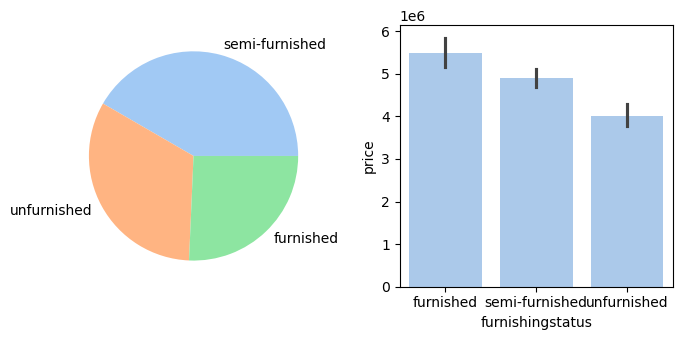

In [43]:
figure, axes = plt.subplots(1, 2)
status_count = cleaned_house_price['furnishingstatus'].value_counts()
status_label = status_count.index
axes[0].pie(status_count, labels=status_label)
sns.barplot(cleaned_house_price, x='furnishingstatus', y='price', ax=axes[1])
plt.show()

From the charts above, we can see that:
- Most of samples are semi-furnished.
- Houses with higher furnishing status are priced higher.

### Analysis 

In [44]:
cleaned_house_price

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


Import the package needed.

In [45]:
import statsmodels.api as sm

A new variable `lr_house_price` is established as a copy of `cleaned_house_price`. The following analysis process will be done on the new variable.

In [46]:
lr_house_price = cleaned_house_price.copy()

We need to set up the dummy variables for the categorical variables first. 

In [50]:
lr_house_price = pd.get_dummies(lr_house_price, drop_first = True, columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                                                             'airconditioning', 'prefarea', 'furnishingstatus'], dtype = int)

In [51]:
lr_house_price

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


Then, we need to separate the dependent variable and independent variables.

`price` is the dependent variable, since our objective is to predict the house price using other possible elements.

In [52]:
y = lr_house_price['price']

In [53]:
X = lr_house_price.drop('price', axis = 1)

Usually, if the correlation coefficient between two independent variables is bigger than 0.8, these two variabels has co-linearity so that one of them should be eliminated.

In [55]:
X.corr().abs() > 0.8

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
area,True,False,False,False,False,False,False,False,False,False,False,False,False
bedrooms,False,True,False,False,False,False,False,False,False,False,False,False,False
bathrooms,False,False,True,False,False,False,False,False,False,False,False,False,False
stories,False,False,False,True,False,False,False,False,False,False,False,False,False
parking,False,False,False,False,True,False,False,False,False,False,False,False,False
mainroad_yes,False,False,False,False,False,True,False,False,False,False,False,False,False
guestroom_yes,False,False,False,False,False,False,True,False,False,False,False,False,False
basement_yes,False,False,False,False,False,False,False,True,False,False,False,False,False
hotwaterheating_yes,False,False,False,False,False,False,False,False,True,False,False,False,False
airconditioning_yes,False,False,False,False,False,False,False,False,False,True,False,False,False


As shown on the correlation table, no two distinguished variables perform a correlation coefficient bigger than 0.8.

In [56]:
X = sm.add_constant(X)
X

,const,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,1.0,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,1.0,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,1.0,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,1.0,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1.0,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1.0,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1.0,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1.0,2910,3,1,1,0,0,0,0,0,0,0,0,0


Next, we use OLS funtion.

In [57]:
model = sm.OLS(y, X).fit()

We use `summary` to see the overall result.

In [58]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Thu, 11 Jun 2026   Prob (F-statistic):          9.07e-123
Time:                        14:47:02   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                            4.277e+04   2.64e+05      0.162      0.872   -4.76e+05    5.62e+05
area                              244.1394     24.289     10.052      0.000     196.425     291.853
bedrooms                         1.148e+05   7.26e+04      1.581      0.114   -2.78e+04    2.57e+05
bathrooms                        9.877e+05   1.03e+05      9.555      0.000    7.85e+05    1.19e+06
stories                          4.508e+05   6.42e+04      7.026      0.000    3.25e+05    5.77e+05
parking                          2.771e+05   5.85e+04      4.735      0.000    1.62e+05    3.92e+05
mainroad_yes                     4.213e+05   1.42e+05      2.962      0.003    1.42e+05    7.01e+05
guestroom_yes                    3.005e+05   1.32e+05      2.282      0.023    4.18e+04    5.59e+05
basement_yes                     3.501e+05    1.1e+05      3.175      0.002    1.33e+05    5.67e+05
hotwaterheating_yes              8.554e+05   2.23e+05      3.833      0.000    4.17e+05    1.29e+06
airconditioning_yes               8.65e+05   1.08e+05      7.983      0.000    6.52e+05    1.08e+06
prefarea_yes                     6.515e+05   1.16e+05      5.632      0.000    4.24e+05    8.79e+05
furnishingstatus_semi-furnished -4.634e+04   1.17e+05     -0.398      0.691   -2.75e+05    1.83e+05
furnishingstatus_unfurnished    -4.112e+05   1.26e+05     -3.258      0.001   -6.59e+05   -1.63e+05
==============================================================================
Omnibus:                       97.909   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.281
Skew:                           0.895   Prob(JB):                     8.22e-57
Kurtosis:                       5.859   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

As shown on the model summary, the `const`, `bedrooms` and `furnishingstatus_semi-furnished` have p-values bigger than 0.05. They do not have a significant influence on the house price.

Therefore, we drop these variables, and see how the model goes.

In [59]:
X = X.drop(['const', 'bedrooms', 'furnishingstatus_semi-furnished'], axis = 1)

In [60]:
model = sm.OLS(y, X).fit()

In [61]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1088.
Date:                Thu, 11 Jun 2026   Prob (F-statistic):                        0.00
Time:                        14:52:19   Log-Likelihood:                         -8333.5
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     534   BIC:                                  1.674e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
area                           257.5854     22.577     11.409      0.000     213.234     301.936
bathrooms                     1.071e+06   9.27e+04     11.553      0.000    8.89e+05    1.25e+06
stories                       5.084e+05   5.71e+04      8.898      0.000    3.96e+05    6.21e+05
parking                       2.793e+05   5.83e+04      4.794      0.000    1.65e+05    3.94e+05
mainroad_yes                  4.672e+05   1.27e+05      3.679      0.000    2.18e+05    7.17e+05
guestroom_yes                 2.851e+05   1.31e+05      2.172      0.030    2.72e+04    5.43e+05
basement_yes                  4.016e+05   1.07e+05      3.765      0.000    1.92e+05    6.11e+05
hotwaterheating_yes           8.668e+05   2.23e+05      3.884      0.000    4.28e+05    1.31e+06
airconditioning_yes           8.543e+05   1.07e+05      7.952      0.000    6.43e+05    1.07e+06
prefarea_yes                  6.443e+05   1.15e+05      5.594      0.000    4.18e+05    8.71e+05
furnishingstatus_unfurnished -3.493e+05   9.49e+04     -3.679      0.000   -5.36e+05   -1.63e+05
==============================================================================
Omnibus:                       94.840   Durbin-Watson:                   1.262
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              251.889
Skew:                           0.865   Prob(JB):                     2.01e-55
Kurtosis:                       5.845   Cond. No.                     2.74e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.74e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

As shown on the new model summary, the $R^2$ value is 0.957, which means the new model fits better the data we have. 

The models shows that the following variables will positive affect the house price:
- `area`
- `bathrooms`
- `stories`
- `parking`
- `mainroad`
- `guestroom`
- `basement`
- `hotwaterheating`
- `airconditioning`
- `prefarea`

While `furnishingstatus` gives a negative effect to the house price.

### Forecasting

#### New House Info:
- Area: 6500$ft^2$,
- Bedrooms: 4,
- Bathrooms: 2,
- Stories: 2,
- Mainroad: No,
- Guestroom: No,
- Basement: Yes,
- Hot water heating: Yes,
- Air conditioning: No,
- Parking spot: 2,
- Preferred area: Yes
- Furnishing status: Semi-furnishing

In [65]:
price_to_predict = pd.DataFrame({'area': [6500], 'bedrooms': [4], 'bathrooms': [2], 
                                'stories': [2], 'mainroad': ['no'], 'guestroom': ['no'],
                                'basement': ['yes'], 'hotwaterheating': ['yes'],
                                'airconditioning': ['no'], 'parking': [2], 
                                'prefarea': ['yes'], 'furnishingstatus': ['semi-furnished']})
price_to_predict

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,6500,4,2,2,no,no,yes,yes,no,2,yes,semi-furnished


In [66]:
price_to_predict['mainroad'] = pd.Categorical(price_to_predict['mainroad'], categories = ['yes', 'no'])
price_to_predict['guestroom'] = pd.Categorical(price_to_predict['guestroom'], categories = ['yes', 'no'])
price_to_predict['basement'] = pd.Categorical(price_to_predict['basement'], categories = ['yes', 'no'])
price_to_predict['hotwaterheating'] = pd.Categorical(price_to_predict['hotwaterheating'], categories = ['yes', 'no'])
price_to_predict['airconditioning'] = pd.Categorical(price_to_predict['airconditioning'], categories = ['yes', 'no'])
price_to_predict['prefarea'] = pd.Categorical(price_to_predict['prefarea'], categories = ['yes', 'no'])
price_to_predict['furnishingstatus'] = pd.Categorical(price_to_predict['furnishingstatus'], categories = ['furnished', 'semi-furnished', 'unfurnished'])


Now we can import dummy variables.

In [67]:
price_to_predict =  pd.get_dummies(price_to_predict, drop_first = True, columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                                                               'airconditioning', 'prefarea', 'furnishingstatus'],
                                   dtype = int)

In [68]:
price_to_predict

,area,bedrooms,bathrooms,stories,parking,mainroad_no,guestroom_no,basement_no,hotwaterheating_no,airconditioning_no,prefarea_no,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,6500,4,2,2,2,1,1,0,0,1,0,1,0


We need to delete the variables that were not used in the model.

In [69]:
price_to_predict = price_to_predict.drop(['bedrooms', 'furnishingstatus_semi-furnished'], axis = 1)


Now we can use the `predict` method to do the prediction.

In [70]:
predicted_value = model.predict(price_to_predict)

In [71]:
predicted_value

0    6.997695e+06
dtype: float64

#### Result

The final prediction is 6997695.